In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
TRAIN_DATA_PATH = os.path.join("../affectnet_dataset/Train")
TEST_DATA_PATH = os.path.join("../affectnet_dataset/Test")
EPOCHS = 50
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (75,75)
SAVED_MODEL = "../saved_models/cnn_weighted_model.h5"
CLASSES = [d for d in os.listdir(TRAIN_DATA_PATH) if d != '.DS_Store']

In [3]:
# one hot encoding (categorical lbl mode)
train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

val_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical",
    validation_split=0.2,
    subset="validation"
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

Found 16108 files belonging to 8 classes.
Using 12887 files for training.
Found 16108 files belonging to 8 classes.
Using 3221 files for validation.
Found 14518 files belonging to 8 classes.


In [4]:
# # CNN works better with 0-1 px values
# layer_normalization = Rescaling(1./255)

# train_dataset = train_dataset.map(lambda x, y: (layer_normalization(x), y))
# test_dataset = test_dataset.map(lambda x, y: (layer_normalization(x),y))

In [5]:
train_counts = {}

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [6]:
# Calculate class weights for imbalanced dataset
# Create label list manually from folder counts
labels = []

for idx, cls in enumerate(CLASSES):
    count = train_counts[cls]
    labels.extend([idx] * count)

labels = np.array(labels)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(zip(range(len(class_weights_array)), class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.3423333333333334), 1: np.float64(1.2915330339961513), 2: np.float64(1.6383238405207485), 3: np.float64(1.3316798941798942), 4: np.float64(0.8604700854700855), 5: np.float64(0.7300580130529369), 6: np.float64(0.6514073115496603), 7: np.float64(0.9502123643227938)}


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [7]:
model = tf.keras.Sequential([
    layers.Input(shape=(75, 75, 3)),
    data_augmentation,
    # Rescaling layer to normalize pixel values to [0, 1] for CNN better performance
    # Rescaling is not needed if using a pretrained model that expects 0-255 input, but since we're building from scratch, it's beneficial to normalize the input.
    # Input normalization can help the model converge faster and improve performance.
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4), metrics=['accuracy'])
model.summary()

NameError: name 'data_augmentation' is not defined

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('../logs/cnn_weighted_loss_training_log.csv')

In [10]:
start = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1550 - loss: 2.5967

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - accuracy: 0.1771 - loss: 2.4982 - val_accuracy: 0.2617 - val_loss: 2.0277
Epoch 2/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.2239 - loss: 2.2184

403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 113ms/step - accuracy: 0.2384 - loss: 2.1661 - val_accuracy: 0.3760 - val_loss: 1.5801
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2755 - loss: 2.0146

403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - accuracy: 0.2847 - loss: 1.9804 - val_accuracy: 0.4101 - val_loss: 1.4946
Epoch 4/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.3048 - loss: 1.8774

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.3150 - loss: 1.8626 - val_accuracy: 0.4182 - val_loss: 1.4624
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3213 - loss: 1.8175

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 59s 147ms/step - accuracy: 0.5445 - loss: 1.2612 - val_accuracy: 0.5784 - val_loss: 1.1069
Epoch 42/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 57s 141ms/step - accuracy: 0.5517 - loss: 1.2510 - val_accuracy: 0.5716 - val_loss: 1.1336
Epoch 43/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5457 - loss: 1.2455

403/403 ━━━━━━━━━━━━━━━━━━━━ 55s 136ms/step - accuracy: 0.5488 - loss: 1.2477 - val_accuracy: 0.5803 - val_loss: 1.1039
Epoch 44/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - accuracy: 0.5471 - loss: 1.2446 - val_accuracy: 0.5787 - val_loss: 1.1285
Epoch 45/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 50s 123ms/step - accuracy: 0.5526 - loss: 1.2423 - val_accuracy: 0.5675 - val_loss: 1.1404
Epoch 46/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5477 - loss: 1.2349

403/403 ━━━━━━━━━━━━━━━━━━━━ 55s 135ms/step - accuracy: 0.5596 - loss: 1.2321 - val_accuracy: 0.5862 - val_loss: 1.1112
Epoch 47/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5547 - loss: 1.2361

403/403 ━━━━━━━━━━━━━━━━━━━━ 51s 127ms/step - accuracy: 0.5581 - loss: 1.2369 - val_accuracy: 0.5865 - val_loss: 1.1073
Epoch 48/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5562 - loss: 1.2192

403/403 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.5626 - loss: 1.2271 - val_accuracy: 0.5924 - val_loss: 1.0947
Epoch 49/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 52s 128ms/step - accuracy: 0.5578 - loss: 1.2315 - val_accuracy: 0.5821 - val_loss: 1.1180
Epoch 50/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.5615 - loss: 1.2264 - val_accuracy: 0.5694 - val_loss: 1.1283
Training time:  40.70277585585912


NameError: name 'history' is not defined

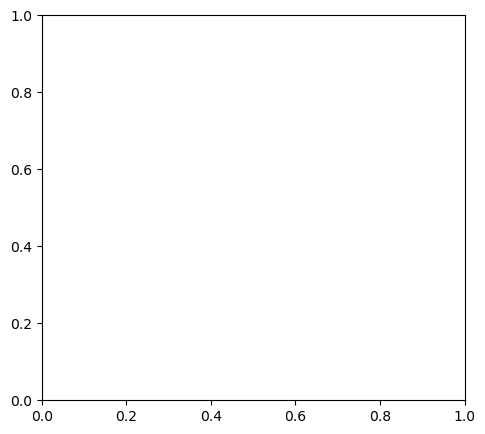

In [8]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# os.stat("../saved_models/weighted_loss_model.h5").st_size

In [ ]:
model = tf.keras.models.load_model(SAVED_MODEL)

ValueError: File format not supported: filepath=../saved_models/weighted_loss_model.h5/. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(../saved_models/weighted_loss_model.h5/, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# # Predict probabilities
# yhat_probs = model.predict(test_dataset)  # shape (num_samples, 8)

# # Convert probabilities to predicted class indices
# yhat = np.argmax(yhat_probs, axis=1)

# # True class indices
# ytrue = np.argmax(CLASSES, axis=1)  # one-hot


# from sklearn.metrics import accuracy_score

# acc = accuracy_score(ytrue, yhat)
# print(f"Test Accuracy: {acc*100:.2f}%")